<h1><b>FAKE NEWS DETECTION - EXPLORATORY DATA ANALYSIS (EDA)

<h2><b> 1. IMPORT LIBRARIES

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

# 2. DOWNLOAD NLTK RESOURCES

In [2]:

nltk.download("punkt")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 3. LOAD DATASET

In [3]:



fake = pd.read_csv(
    "Fake.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

# Load Real News Dataset


true = pd.read_csv(
    "True.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)


print("\nFake Dataset Shape:", fake.shape)
print("Real Dataset Shape:", true.shape)



Fake Dataset Shape: (23481, 4)
Real Dataset Shape: (21417, 4)


# 4. CREATE TARGET LABEL

In [4]:


# 0 = Fake News
# 1 = Real News

fake["label"] = 0
true["label"] = 1

# 5. COMBINE DATASETS

In [5]:

df = pd.concat(
    [fake, true],
    ignore_index=True
)


print("\nCombined Dataset Shape:", df.shape)


Combined Dataset Shape: (44898, 5)


# 6. DISPLAY COLUMN NAMES

In [6]:

print("\nDataset Columns:")
print(df.columns.tolist())



Dataset Columns:
['title', 'text', 'subject', 'date', 'label']


# 7. CHECK REQUIRED COLUMNS

In [7]:


required_columns = [
    "title",
    "text",
    "subject",
    "date",
    "label"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("\nERROR: Missing Columns:")
    print(missing_columns)

else:
    print("\nAll required columns are available.")



All required columns are available.


# 8. BASIC DATASET INFORMATION

In [8]:


print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
df.info()


Dataset Shape:
(44898, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


# 9. FIRST FIVE RECORDS

In [9]:

print("\nFirst 5 Records:")
print(df.head())



First 5 Records:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  


# 10. MISSING VALUES

In [10]:

missing_values = df.isnull().sum()

print(missing_values)

title      0
text       0
subject    0
date       0
label      0
dtype: int64


# 11. DUPLICATE RECORDS

In [11]:

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)


Number of Duplicate Records: 209


# 12. REMOVE DUPLICATES

In [12]:


df = df.drop_duplicates().reset_index(drop=True)

print(
    "Dataset Shape After Removing Duplicates:",
    df.shape
)


Dataset Shape After Removing Duplicates: (44689, 5)


# 13. HANDLE MISSING TEXT VALUES

In [13]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
df["subject"] = df["subject"].fillna("Unknown")
df["date"] = df["date"].fillna("")

# 14. CLASS DISTRIBUTION

In [14]:


class_counts = df["label"].value_counts().sort_index()

print("\nClass Counts:")
print(class_counts)

class_percentage = (
    df["label"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nClass Percentage:")
print(class_percentage)


Class Counts:
label
0    23478
1    21211
Name: count, dtype: int64

Class Percentage:
label
0    52.536418
1    47.463582
Name: proportion, dtype: float64


# 15. CLASS DISTRIBUTION PLOT

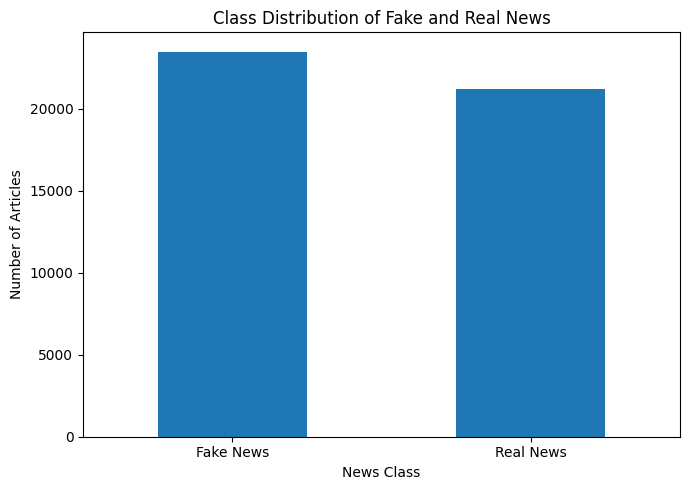

In [15]:

plt.figure(figsize=(7, 5))

class_counts.plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["Fake News", "Real News"],
    rotation=0
)

plt.title("Class Distribution of Fake and Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()


# 16. SUBJECT DISTRIBUTION

In [16]:


subject_counts = df["subject"].value_counts()

print(subject_counts)


subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


# 17. SUBJECT DISTRIBUTION PLOT

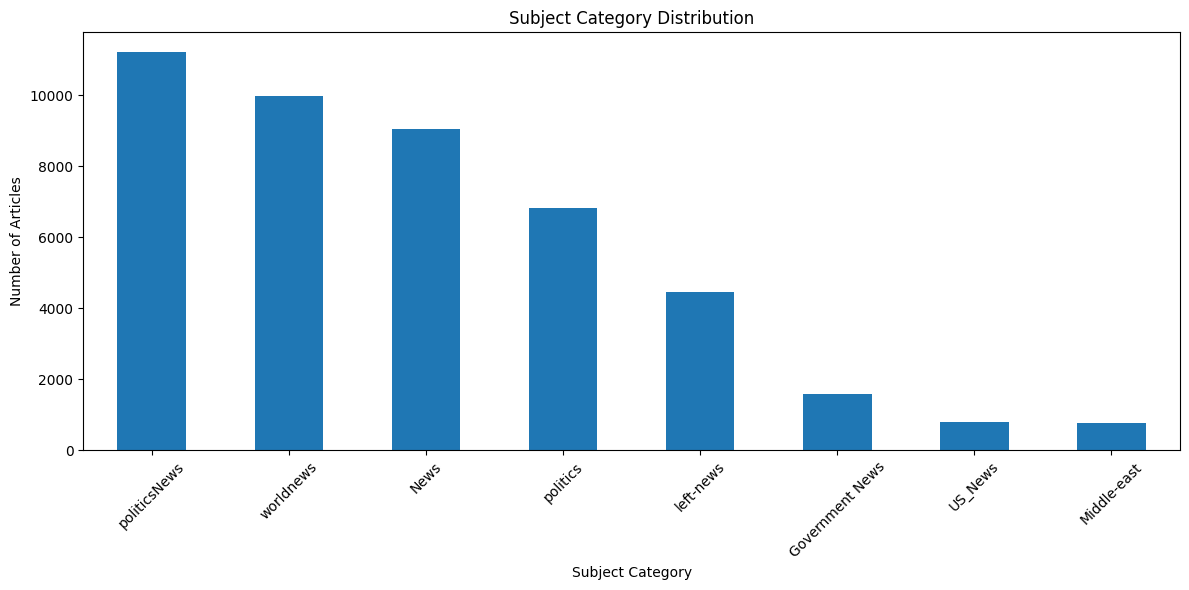

In [17]:


plt.figure(figsize=(12, 6))

subject_counts.plot(
    kind="bar"
)

plt.title("Subject Category Distribution")
plt.xlabel("Subject Category")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 18. DATE PROCESSING

In [18]:

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# 19. EXTRACT YEAR AND MONTH

In [19]:


df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month


# 20. TEMPORAL ANALYSIS - YEAR

In [20]:

year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
)

print("\nArticles Published by Year:")
print(year_counts)



Articles Published by Year:
year
2015.0     338
2016.0    7077
2017.0    4453
Name: count, dtype: int64


# 21. ARTICLES BY YEAR PLOT

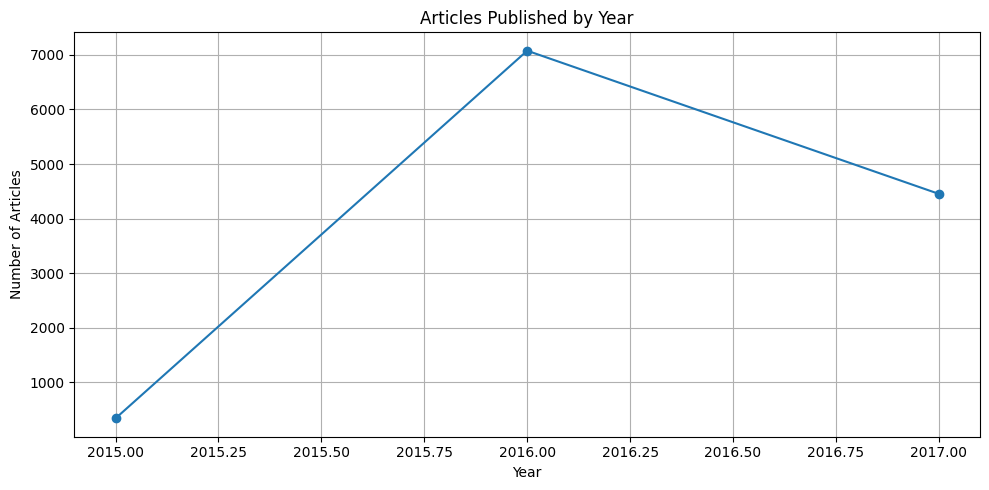

In [21]:

plt.figure(figsize=(10, 5))

year_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Articles Published by Year")
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.grid(True)

plt.tight_layout()
plt.show()


# 22. TITLE LENGTH FEATURES

In [22]:
df["title_char_count"] = (
    df["title"]
    .astype(str)
    .apply(len)
)


df["title_word_count"] = (
    df["title"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)


# 23. AVERAGE TITLE LENGTH BY CLASS

In [23]:


title_length_summary = (
    df.groupby("label")
    [
        [
            "title_char_count",
            "title_word_count"
        ]
    ]
    .mean()
)

print(title_length_summary)

       title_char_count  title_word_count
label                                    
0             94.194054         14.732388
1             64.658291          9.951582


# 24. TITLE LENGTH DISTRIBUTION

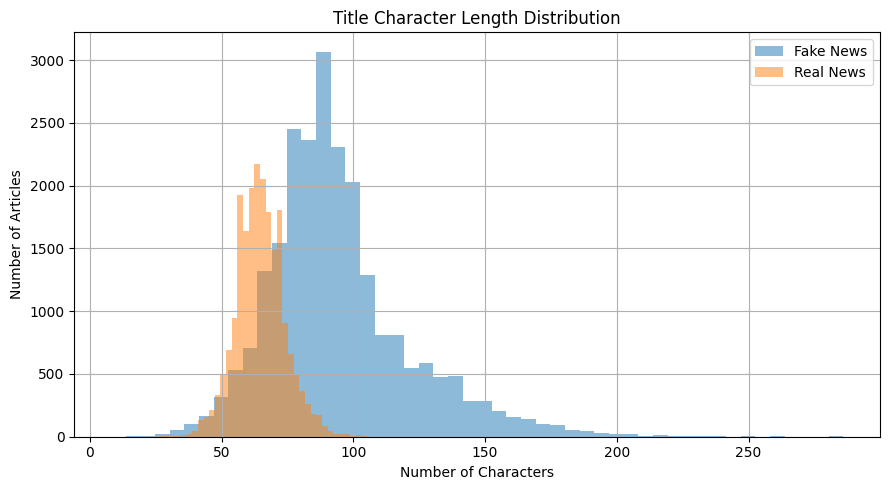

In [24]:

plt.figure(figsize=(9, 5))

for label, name in zip(
    [0, 1],
    ["Fake News", "Real News"]
):

    df[
        df["label"] == label
    ]["title_char_count"].hist(
        bins=50,
        alpha=0.5,
        label=name
    )


plt.legend()

plt.title(
    "Title Character Length Distribution"
)

plt.xlabel(
    "Number of Characters"
)

plt.ylabel(
    "Number of Articles"
)

plt.tight_layout()
plt.show()

# 25. TEXT LENGTH FEATURES

In [25]:

df["text_char_count"] = (
    df["text"]
    .astype(str)
    .apply(len)
)


df["word_count"] = (
    df["text"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)


# 26. AVERAGE TEXT LENGTH BY CLASS

In [26]:


text_length_summary = (
    df.groupby("label")
    [
        [
            "text_char_count",
            "word_count"
        ]
    ]
    .mean()
)

print(text_length_summary)

       text_char_count  word_count
label                             
0          2547.555882  423.224167
1          2378.042337  384.757484


# 27. WORD COUNT DISTRIBUTION

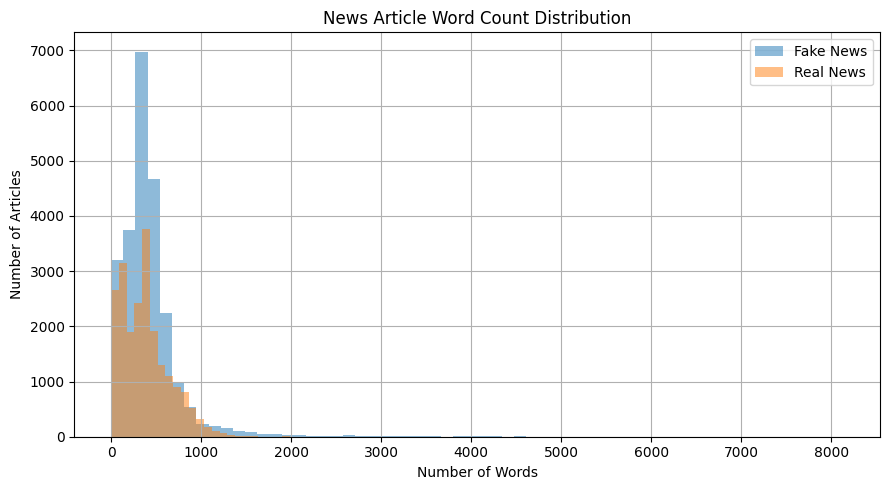

In [27]:


plt.figure(figsize=(9, 5))

for label, name in zip(
    [0, 1],
    ["Fake News", "Real News"]
):

    df[
        df["label"] == label
    ]["word_count"].hist(
        bins=60,
        alpha=0.5,
        label=name
    )


plt.legend()

plt.title(
    "News Article Word Count Distribution"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Number of Articles"
)

plt.tight_layout()
plt.show()

# 28. PUNCTUATION ANALYSIS

In [28]:

df["exclamation_count"] = (
    df["text"]
    .astype(str)
    .apply(
        lambda x: x.count("!")
    )
)


df["question_count"] = (
    df["text"]
    .astype(str)
    .apply(
        lambda x: x.count("?")
    )
)


# 29. PUNCTUATION SUMMARY

In [29]:


punctuation_summary = (
    df.groupby("label")
    [
        [
            "exclamation_count",
            "question_count"
        ]
    ]
    .mean()
)

print(punctuation_summary)

       exclamation_count  question_count
label                                   
0               0.722847        1.205682
1               0.062090        0.100325


# 30. UPPERCASE RATIO

In [30]:


def uppercase_ratio(text):

    text = str(text)

    # Keep only alphabetic characters
    letters = [
        char for char in text
        if char.isalpha()
    ]

    if len(letters) == 0:
        return 0

    uppercase_letters = sum(
        1
        for char in letters
        if char.isupper()
    )

    return uppercase_letters / len(letters)


df["uppercase_ratio"] = (
    df["text"]
    .apply(uppercase_ratio)
)


# 31. UPPERCASE RATIO SUMMARY

In [31]:


uppercase_summary = (
    df.groupby("label")
    ["uppercase_ratio"]
    .mean()
)

print(uppercase_summary)

label
0    0.057309
1    0.052020
Name: uppercase_ratio, dtype: float64


# 32. SUBJECT VS CLASS

In [32]:


subject_class = pd.crosstab(
    df["subject"],
    df["label"]
)

# Rename columns
subject_class.columns = [
    "Fake News",
    "Real News"
]

print(subject_class)


                 Fake News  Real News
subject                              
Government News       1570          0
Middle-east            778          0
News                  9050          0
US_News                783          0
left-news             4459          0
politics              6838          0
politicsNews             0      11220
worldnews                0       9991


# 33. SUBJECT VS CLASS PLOT

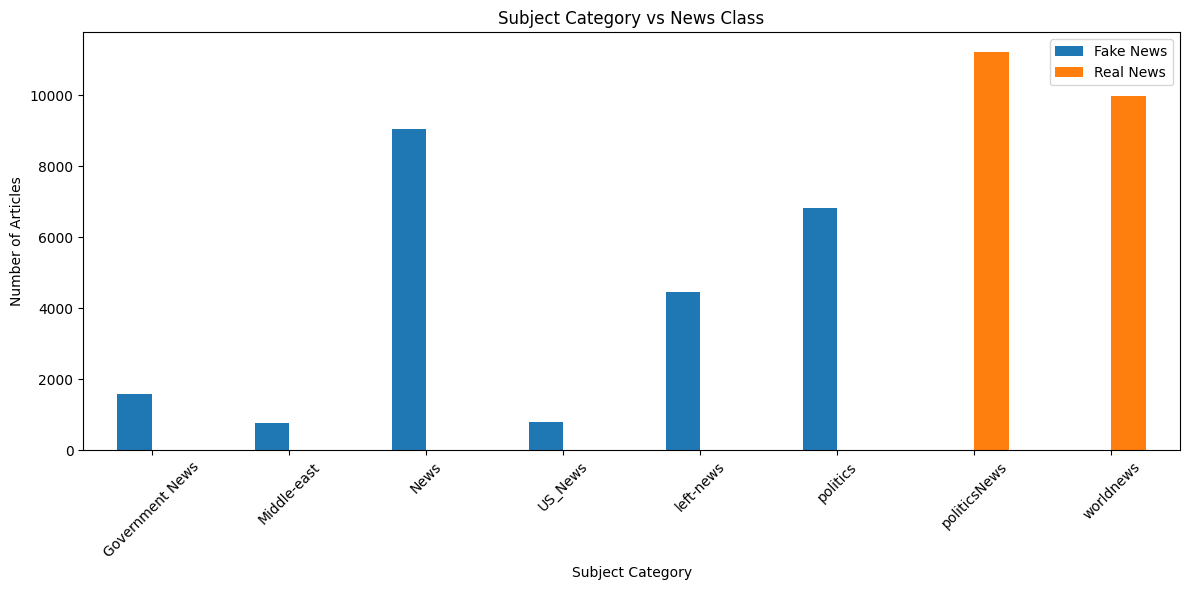

In [33]:


subject_class.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Subject Category vs News Class"
)

plt.xlabel(
    "Subject Category"
)

plt.ylabel(
    "Number of Articles"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 34. STOPWORDS

In [34]:
stop_words = set(
    stopwords.words("english")
)


# 35. TOP WORDS FUNCTION

In [35]:



def get_top_words(
    text_series,
    n=20
):

    words = []

    for text in text_series:

        # Convert to lowercase
        text = str(text).lower()

        # Split text
        tokens = text.split()

        # Clean punctuation
        tokens = [
            word.strip(
                ".,!?;:\"'()[]{}<>"
            )
            for word in tokens
        ]

        # Keep alphabetic words
        # Remove stopwords
        tokens = [
            word
            for word in tokens
            if word.isalpha()
            and word not in stop_words
            and len(word) > 2
        ]

        words.extend(tokens)

    return Counter(
        words
    ).most_common(n)

# TOP WORDS - FAKE NEWS and REAL NEWS

[('trump', 73291), ('said', 31005), ('people', 25937), ('president', 25463), ('would', 23419), ('one', 22858), ('clinton', 17945), ('obama', 17746), ('like', 17593), ('donald', 17098), ('also', 15221), ('new', 14135), ('news', 14087), ('even', 13655), ('hillary', 13496), ('white', 12762), ('time', 12664), ('state', 12494), ('via', 11140), ('media', 10976)]
[('said', 97822), ('trump', 41580), ('would', 31062), ('reuters', 28010), ('president', 24949), ('state', 18347), ('government', 17578), ('new', 16554), ('house', 16146), ('states', 15832), ('also', 15735), ('united', 15345), ('republican', 15185), ('people', 14413), ('told', 14070), ('could', 13475), ('last', 12438), ('one', 12154), ('washington', 11997), ('two', 11441)]


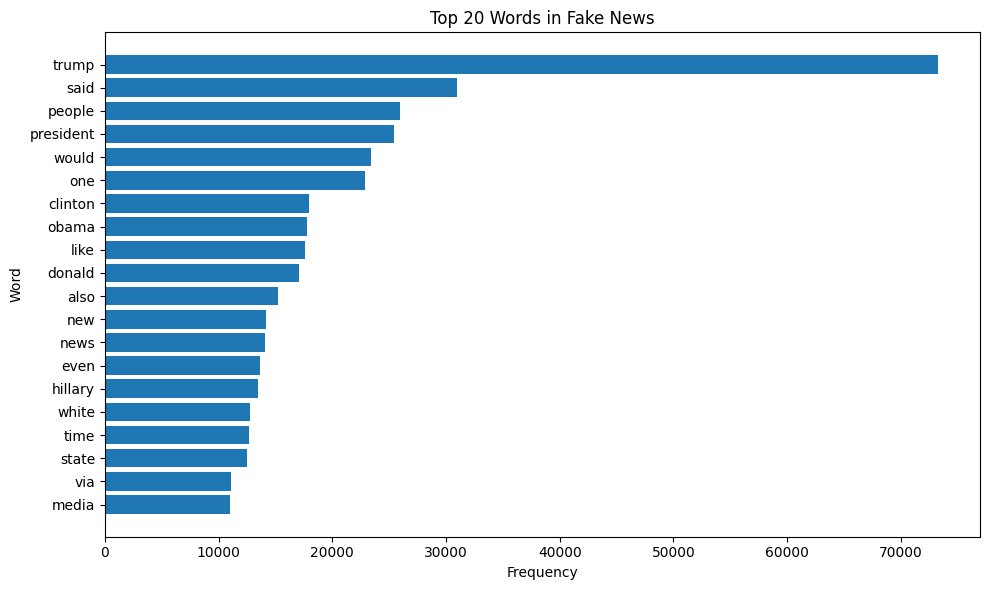

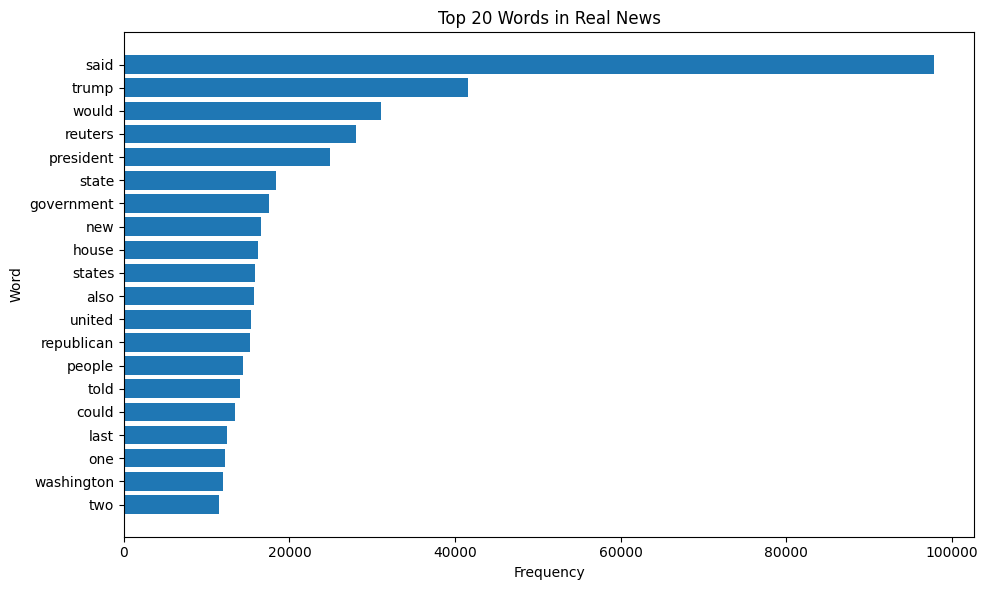

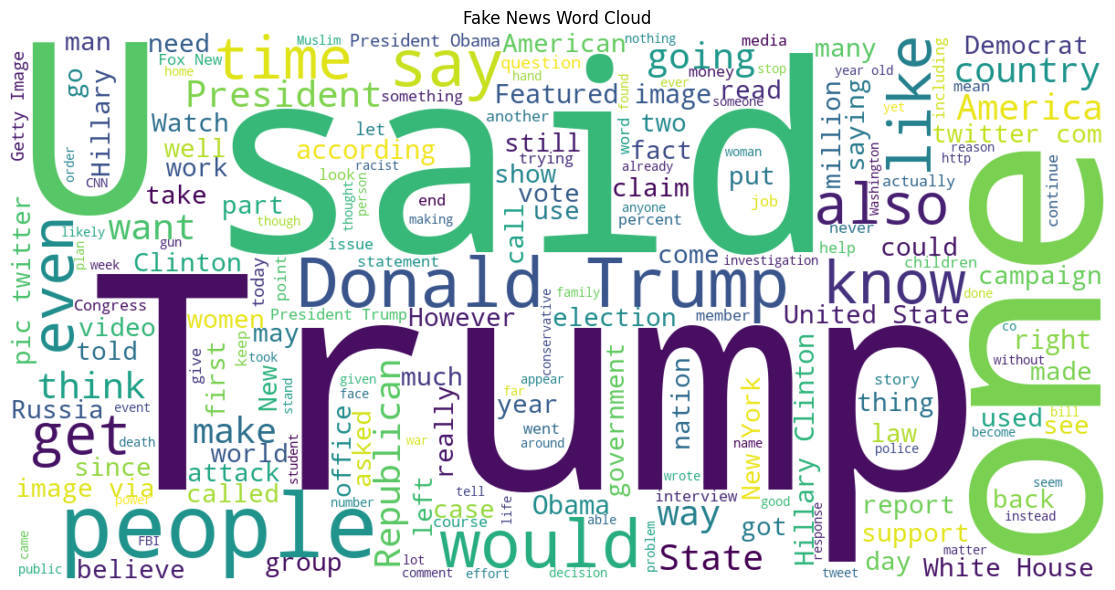

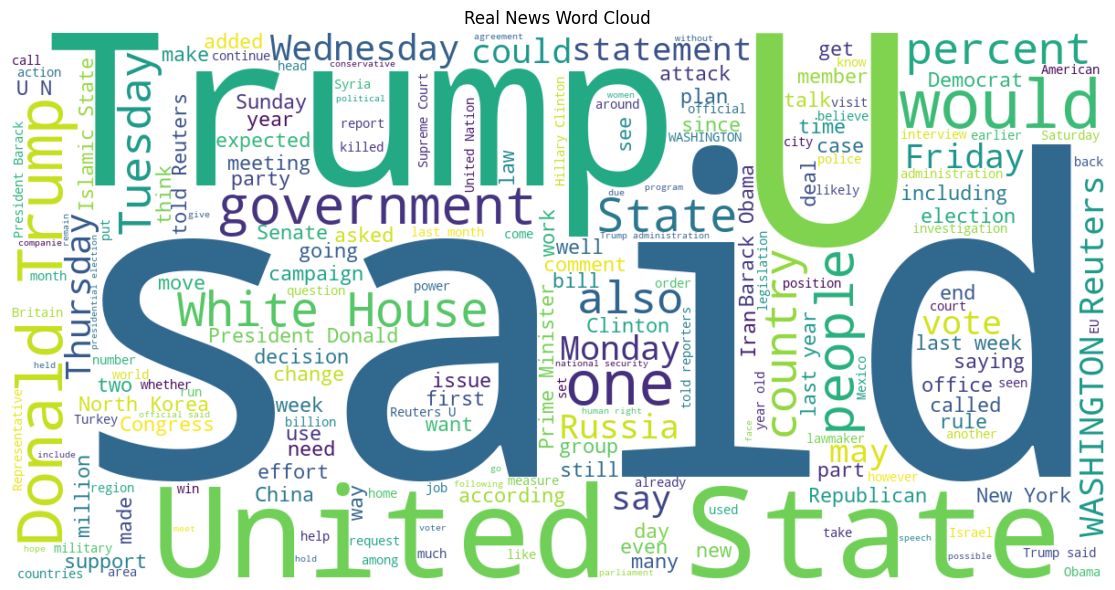

FINAL EDA SUMMARY
           title_char_count  title_word_count  text_char_count  word_count  \
Fake News         94.194054         14.732388      2547.555882  423.224167   
Real News         64.658291          9.951582      2378.042337  384.757484   

           exclamation_count  question_count  uppercase_ratio  
Fake News           0.722847        1.205682         0.057309  
Real News           0.062090        0.100325         0.052020  
FINAL DATASET INFORMATION
Final Dataset Shape: (44689, 14)
Fake News Records: 23478
Real News Records: 21211
Duplicate Records: 4
Missing Values:
title                    0
text                     0
subject                  0
date                 32821
label                    0
year                 32821
month                32821
title_char_count         0
title_word_count         0
text_char_count          0
word_count               0
exclamation_count        0
question_count           0
uppercase_ratio          0
dtype: int64
EDA COMPLETED SUCC

In [36]:


fake_words = get_top_words(
    df[
        df["label"] == 0
    ]["text"],
    n=20
)


print(
    fake_words
)



real_words = get_top_words(
    df[
        df["label"] == 1
    ]["text"],
    n=20
)




print(
    real_words
)


fake_word_df = pd.DataFrame(
    fake_words,
    columns=[
        "Word",
        "Frequency"
    ]
)


plt.figure(figsize=(10, 6))

plt.barh(
    fake_word_df["Word"][::-1],
    fake_word_df["Frequency"][::-1]
)

plt.title(
    "Top 20 Words in Fake News"
)

plt.xlabel(
    "Frequency"
)

plt.ylabel(
    "Word"
)

plt.tight_layout()
plt.show()



real_word_df = pd.DataFrame(
    real_words,
    columns=[
        "Word",
        "Frequency"
    ]
)


plt.figure(figsize=(10, 6))

plt.barh(
    real_word_df["Word"][::-1],
    real_word_df["Frequency"][::-1]
)

plt.title(
    "Top 20 Words in Real News"
)

plt.xlabel(
    "Frequency"
)

plt.ylabel(
    "Word"
)

plt.tight_layout()
plt.show()


fake_text = " ".join(
    df[
        df["label"] == 0
    ]["text"]
    .astype(str)
)


if len(fake_text.strip()) > 0:

    wc_fake = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stop_words,
        max_words=200
    ).generate(fake_text)


    plt.figure(
        figsize=(12, 6)
    )

    plt.imshow(
        wc_fake,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        "Fake News Word Cloud"
    )

    plt.tight_layout()
    plt.show()



real_text = " ".join(
    df[
        df["label"] == 1
    ]["text"]
    .astype(str)
)


if len(real_text.strip()) > 0:

    wc_real = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stop_words,
        max_words=200
    ).generate(real_text)


    plt.figure(
        figsize=(12, 6)
    )

    plt.imshow(
        wc_real,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        "Real News Word Cloud"
    )

    plt.tight_layout()
    plt.show()




eda_summary = (
    df.groupby("label")
    [
        [
            "title_char_count",
            "title_word_count",
            "text_char_count",
            "word_count",
            "exclamation_count",
            "question_count",
            "uppercase_ratio"
        ]
    ]
    .mean()
)


# Rename index
eda_summary.index = [
    "Fake News",
    "Real News"
]



print("FINAL EDA SUMMARY")


print(
    eda_summary
)




eda_summary.to_csv(
    "eda_summary.csv"
)


# ============================================================
# 45. SAVE PROCESSED DATASET
# ============================================================

df.to_csv(
    "fake_news_eda_processed.csv",
    index=False
)




print("FINAL DATASET INFORMATION")


print(
    "Final Dataset Shape:",
    df.shape
)

print(
    "Fake News Records:",
    (df["label"] == 0).sum()
)

print(
    "Real News Records:",
    (df["label"] == 1).sum()
)

print(
    "Duplicate Records:",
    df.duplicated().sum()
)

print(
    "Missing Values:"
)

print(
    df.isnull().sum()
)




print("EDA COMPLETED SUCCESSFULLY")


print(
    "\nProcessed dataset saved at:"
)

print(
    "fake_news_eda_processed.csv"
)

print(
    "\nEDA summary saved at:"
)

print(
    "eda_summary.csv"
)

# PHASE 2 — FEATURE ENGINEERING

## IMPORT LIBRARIES

In [37]:

!pip install -q textstat
!pip install textblob




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

from textblob import TextBlob
import textstat

import sys
!{sys.executable} -m pip install spacy

import spacy


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##  DOWNLOAD NLTK RESOURCES

In [38]:

nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)


True

## LOAD SPACY MODEL

In [39]:
# If model is not installed, run:
!python -m spacy download en_core_web_sm

nlp = spacy.load(
    "en_core_web_sm",
    disable=["tagger", "parser", "lemmatizer"]
)




[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 325.1 kB/s eta 0:00:40
     --------------------------------------- 0.1/12.8 MB 901.1 kB/s eta 0:00:15
     - -------------------------------------- 0.6/12.8 MB 3.6 MB/s eta 0:00:04
     --- ------------------------------------ 1.2/12.8 MB 5.7 MB/s eta 0:00:03
     ----- ---------------------------------- 1.9/12.8 MB 7.1 MB/s eta 0:00:02
     ------- -------------------------------- 2.3/12.8 MB 7.4 MB/s eta 0:00:02
     -------- ------------------------------- 2.9/12.8 MB 8.0 MB/s eta 0:00:02
     ---------- ----------------------------- 3.3/12.8 MB 8.2 MB/s eta 0:00:02
     ----------- ---------------------------- 3.6/12.8 MB 8.0 MB/s eta 0:00:02
     ------------ --------------------------- 4.0/12.8 MB 7.9 MB/s eta 0:00:02
     -------------- ------------------------- 4.5/12.8 MB 8.2 MB

##  PREPARE DATA

In [40]:


df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["combined_text"] = (
    df["title"] + " " + df["text"]
)


print("PHASE 2 — FEATURE ENGINEERING")


print("Dataset Shape:", df.shape)


PHASE 2 — FEATURE ENGINEERING
Dataset Shape: (44689, 15)


### PART A — TF-IDF

In [41]:


print("\nCalculating TF-IDF Features...")




title_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_title_tfidf = title_tfidf.fit_transform(
    df["title"]
)

print(
    "Title TF-IDF Shape:",
    X_title_tfidf.shape
)




body_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_body_tfidf = body_tfidf.fit_transform(
    df["text"]
)

print(
    "Body TF-IDF Shape:",
    X_body_tfidf.shape
)



Calculating TF-IDF Features...
Title TF-IDF Shape: (44689, 10000)
Body TF-IDF Shape: (44689, 10000)


### PART B — VADER SENTIMENT

In [42]:

print("\nCalculating VADER Sentiment...")

sia = SentimentIntensityAnalyzer()

vader_scores = df["combined_text"].apply(
    sia.polarity_scores
)

df["vader_positive"] = vader_scores.apply(
    lambda x: x["pos"]
)

df["vader_negative"] = vader_scores.apply(
    lambda x: x["neg"]
)

df["vader_neutral"] = vader_scores.apply(
    lambda x: x["neu"]
)

df["vader_compound"] = vader_scores.apply(
    lambda x: x["compound"]
)



Calculating VADER Sentiment...


### PART C — TEXTBLOB SENTIMENT

In [43]:


print("Calculating TextBlob Features...")


df["textblob_polarity"] = (
    df["combined_text"]
    .apply(
        lambda x: TextBlob(x).sentiment.polarity
    )
)


df["textblob_subjectivity"] = (
    df["combined_text"]
    .apply(
        lambda x: TextBlob(x).sentiment.subjectivity
    )
)



Calculating TextBlob Features...


### PART D — READABILITY

In [44]:


print("Calculating Readability Features...")


df["flesch_kincaid_grade"] = (
    df["combined_text"]
    .apply(
        textstat.flesch_kincaid_grade
    )
)


df["gunning_fog"] = (
    df["combined_text"]
    .apply(
        textstat.gunning_fog
    )
)


Calculating Readability Features...


### PART E — STYLOMETRIC FEATURES

In [45]:

print("Calculating Stylometric Features...")


stop_words = set(
    stopwords.words("english")
)


def get_stylometric_features(text):

    text = str(text)

    words = text.split()

    word_count = len(words)

    # Unique Word Ratio
    if word_count > 0:

        unique_word_ratio = (
            len(
                set(
                    word.lower()
                    for word in words
                )
            )
            / word_count
        )

    else:

        unique_word_ratio = 0


    # Average Word Length
    valid_words = [
        word.strip(
            ".,!?;:\"'()[]{}"
        )
        for word in words
        if word.strip(
            ".,!?;:\"'()[]{}"
        ).isalpha()
    ]


    if valid_words:

        avg_word_length = np.mean(
            [
                len(word)
                for word in valid_words
            ]
        )

    else:

        avg_word_length = 0


    # Uppercase Ratio
    letters = [
        c for c in text
        if c.isalpha()
    ]

    if letters:

        uppercase_ratio = (
            sum(
                c.isupper()
                for c in letters
            )
            / len(letters)
        )

    else:

        uppercase_ratio = 0


    # Punctuation
    exclamation_count = text.count("!")

    question_count = text.count("?")


    # Stopword Density
    if word_count > 0:

        stopword_count = sum(
            word.lower().strip(
                ".,!?;:\"'()[]{}"
            )
            in stop_words
            for word in words
        )

        stopword_density = (
            stopword_count
            / word_count
        )

    else:

        stopword_density = 0


    return pd.Series({

        "fe_word_count":
            word_count,

        "unique_word_ratio":
            unique_word_ratio,

        "avg_word_length":
            avg_word_length,

        "fe_uppercase_ratio":
            uppercase_ratio,

        "fe_exclamation_count":
            exclamation_count,

        "fe_question_count":
            question_count,

        "stopword_density":
            stopword_density

    })


stylometric_results = (
    df["combined_text"]
    .apply(get_stylometric_features)
)


df = pd.concat(
    [
        df,
        stylometric_results
    ],
    axis=1
)


Calculating Stylometric Features...


### PART F — NAMED ENTITY RECOGNITION

In [46]:


print("\nCalculating Named Entity Features...")
print("Using optimized NER processing...")

# Keep only the NER component
nlp.select_pipes(enable=["ner"])


# Make sure there are no missing values
df["ner_text"] = df["combined_text"].fillna("").astype(str)


# Limit text length to make NER much faster
# 5000 characters is usually enough for these features
df["ner_text"] = df["ner_text"].str[:5000]


def count_entities(doc):

    person = 0
    org = 0
    gpe = 0

    for ent in doc.ents:

        if ent.label_ == "PERSON":
            person += 1

        elif ent.label_ == "ORG":
            org += 1

        elif ent.label_ == "GPE":
            gpe += 1

    return person, org, gpe


ner_results = []


for doc in nlp.pipe(
    df["ner_text"],
    batch_size=100
):

    ner_results.append(count_entities(doc))


# Convert results into DataFrame
ner_df = pd.DataFrame(
    ner_results,
    columns=[
        "person_entity_count",
        "org_entity_count",
        "gpe_entity_count"
    ],
    index=df.index
)


# Add features to original dataframe
df = pd.concat(
    [
        df,
        ner_df
    ],
    axis=1
)


# Remove temporary column
df.drop(columns=["ner_text"], inplace=True)


print("\nNER features successfully created!")

print(
    df[
        [
            "person_entity_count",
            "org_entity_count",
            "gpe_entity_count"
        ]
    ].head()
)


Calculating Named Entity Features...
Using optimized NER processing...

NER features successfully created!
   person_entity_count  org_entity_count  gpe_entity_count
0                   20                 8                 5
1                   18                 8                 4
2                   22                12                 3
3                   16                19                 5
4                   19                 3                 5


### PART G — FEATURE LIST

In [47]:


feature_columns = [

    # VADER
    "vader_positive",
    "vader_negative",
    "vader_neutral",
    "vader_compound",

    # TextBlob
    "textblob_polarity",
    "textblob_subjectivity",

    # Readability
    "flesch_kincaid_grade",
    "gunning_fog",

    # Stylometry
    "fe_word_count",
    "unique_word_ratio",
    "avg_word_length",
    "fe_uppercase_ratio",
    "fe_exclamation_count",
    "fe_question_count",
    "stopword_density",

    # NER
    "person_entity_count",
    "org_entity_count",
    "gpe_entity_count"

]

### PART H — FEATURE SUMMARY

In [48]:



print("PHASE 2 FEATURE SUMMARY")


print(
    "Number of Numerical Features:",
    len(feature_columns)
)

print("\nFeature Names:")

for i, feature in enumerate(
    feature_columns,
    1
):

    print(
        i,
        feature
    )

PHASE 2 FEATURE SUMMARY
Number of Numerical Features: 18

Feature Names:
1 vader_positive
2 vader_negative
3 vader_neutral
4 vader_compound
5 textblob_polarity
6 textblob_subjectivity
7 flesch_kincaid_grade
8 gunning_fog
9 fe_word_count
10 unique_word_ratio
11 avg_word_length
12 fe_uppercase_ratio
13 fe_exclamation_count
14 fe_question_count
15 stopword_density
16 person_entity_count
17 org_entity_count
18 gpe_entity_count


### PART I — FEATURE STATISTICS BY CLASS

In [49]:


feature_summary = (
    df.groupby("label")
    [feature_columns]
    .mean()
)



print("FEATURE STATISTICS BY CLASS")


print(
    feature_summary
)


FEATURE STATISTICS BY CLASS
       vader_positive  vader_negative  vader_neutral  vader_compound  \
label                                                                  
0            0.093008        0.101713       0.805284       -0.109154   
1            0.081896        0.078892       0.839206        0.054736   

       textblob_polarity  textblob_subjectivity  flesch_kincaid_grade  \
label                                                                   
0               0.056892               0.452130             11.617872   
1               0.053836               0.360995             13.287009   

       gunning_fog  fe_word_count  unique_word_ratio  avg_word_length  \
label                                                                   
0        14.232543     437.956555           0.611971         4.700333   
1        16.061549     394.709066           0.611781         5.055510   

       fe_uppercase_ratio  fe_exclamation_count  fe_question_count  \
label                      

### PART J — SENTIMENT ANALYSIS

In [50]:


sentiment_columns = [

    "vader_positive",
    "vader_negative",
    "vader_neutral",
    "vader_compound",

    "textblob_polarity",
    "textblob_subjectivity"

]


sentiment_by_class = (
    df.groupby("label")
    [sentiment_columns]
    .mean()
)


print("\nSentiment Features by Class:")

print(
    sentiment_by_class
)



Sentiment Features by Class:
       vader_positive  vader_negative  vader_neutral  vader_compound  \
label                                                                  
0            0.093008        0.101713       0.805284       -0.109154   
1            0.081896        0.078892       0.839206        0.054736   

       textblob_polarity  textblob_subjectivity  
label                                            
0               0.056892               0.452130  
1               0.053836               0.360995  


### PART K — READABILITY ANALYSIS

In [51]:


readability_columns = [

    "flesch_kincaid_grade",
    "gunning_fog"

]


readability_by_class = (
    df.groupby("label")
    [readability_columns]
    .mean()
)


print("\nReadability Features by Class:")

print(
    readability_by_class
)



Readability Features by Class:
       flesch_kincaid_grade  gunning_fog
label                                   
0                 11.617872    14.232543
1                 13.287009    16.061549


### PART L — STYLOMETRIC ANALYSIS

In [52]:


stylometry_columns = [

    "fe_word_count",
    "unique_word_ratio",
    "avg_word_length",
    "fe_uppercase_ratio",
    "fe_exclamation_count",
    "fe_question_count",
    "stopword_density"

]


stylometry_by_class = (
    df.groupby("label")
    [stylometry_columns]
    .mean()
)


print("\nStylometric Features by Class:")

print(
    stylometry_by_class
)



Stylometric Features by Class:
       fe_word_count  unique_word_ratio  avg_word_length  fe_uppercase_ratio  \
label                                                                          
0         437.956555           0.611971         4.700333            0.090882   
1         394.709066           0.611781         5.055510            0.052357   

       fe_exclamation_count  fe_question_count  stopword_density  
label                                                             
0                  0.876352           1.279794          0.423530  
1                  0.062986           0.106926          0.374714  


### PART M — NER ANALYSIS

In [53]:


ner_columns = [

    "person_entity_count",
    "org_entity_count",
    "gpe_entity_count"

]


ner_by_class = (
    df.groupby("label")
    [ner_columns]
    .mean()
)


print("\nNamed Entity Features by Class:")

print(
    ner_by_class
)



Named Entity Features by Class:
       person_entity_count  org_entity_count  gpe_entity_count
label                                                         
0                11.655465          9.156998          4.688517
1                 8.850974         11.271746         10.842157


### PART N — VISUALIZATIONS

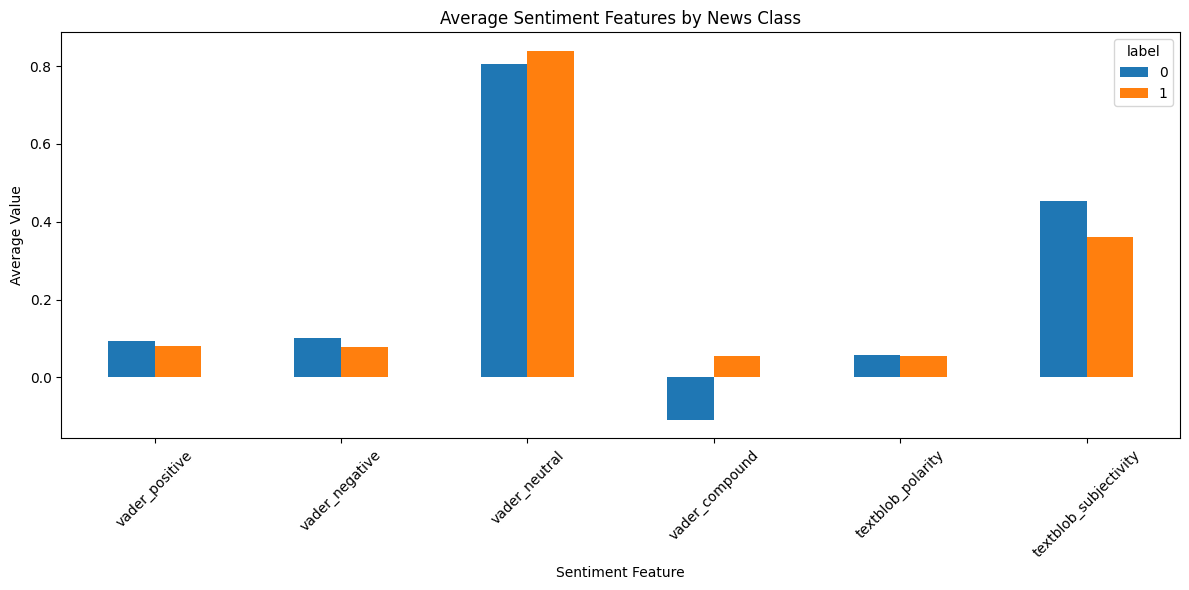

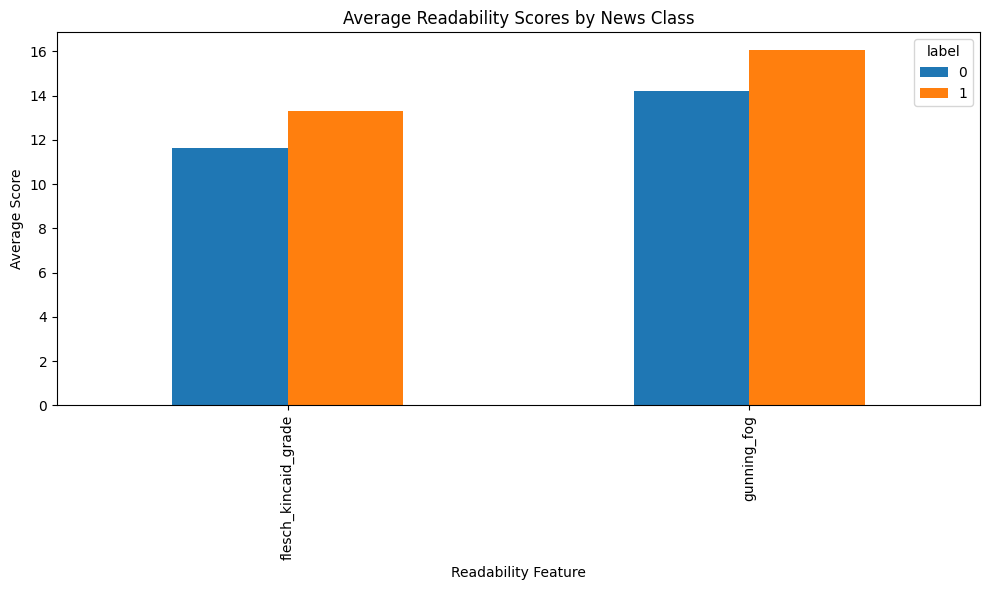

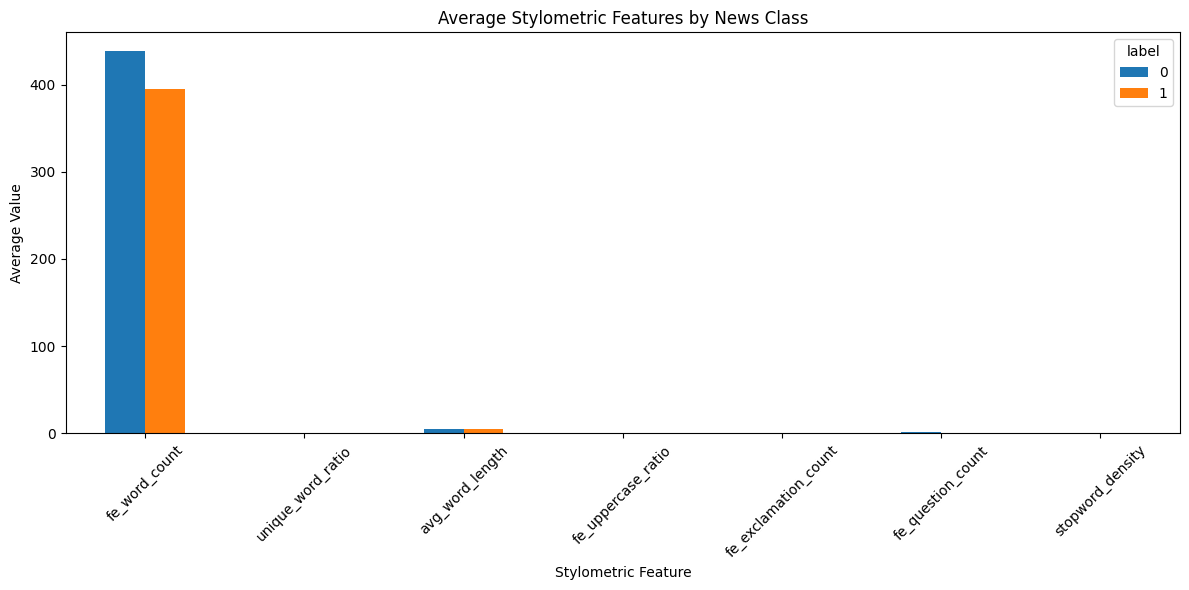

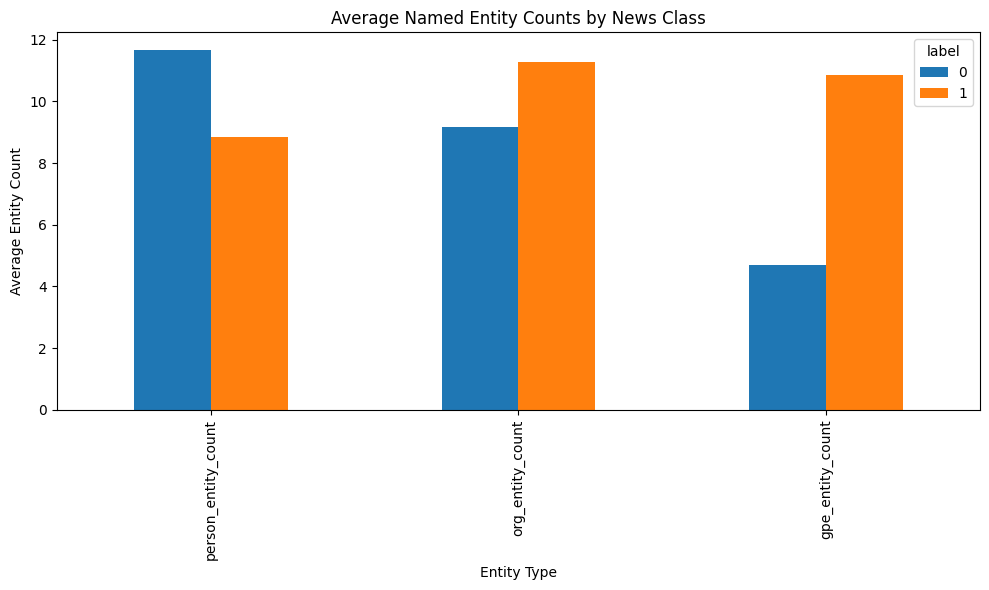

C:\Users\DELL\AppData\Local\Temp\ipykernel_16928\2913657970.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fake_values, real_values], labels=["Fake", "Real"], showfliers=False)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16928\2913657970.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fake_values, real_values], labels=["Fake", "Real"], showfliers=False)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16928\2913657970.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fake_values, real_values], labels=["Fake", "Real"], showfliers=False)
C:\Users\DELL\AppData\Local\Temp\ipykern

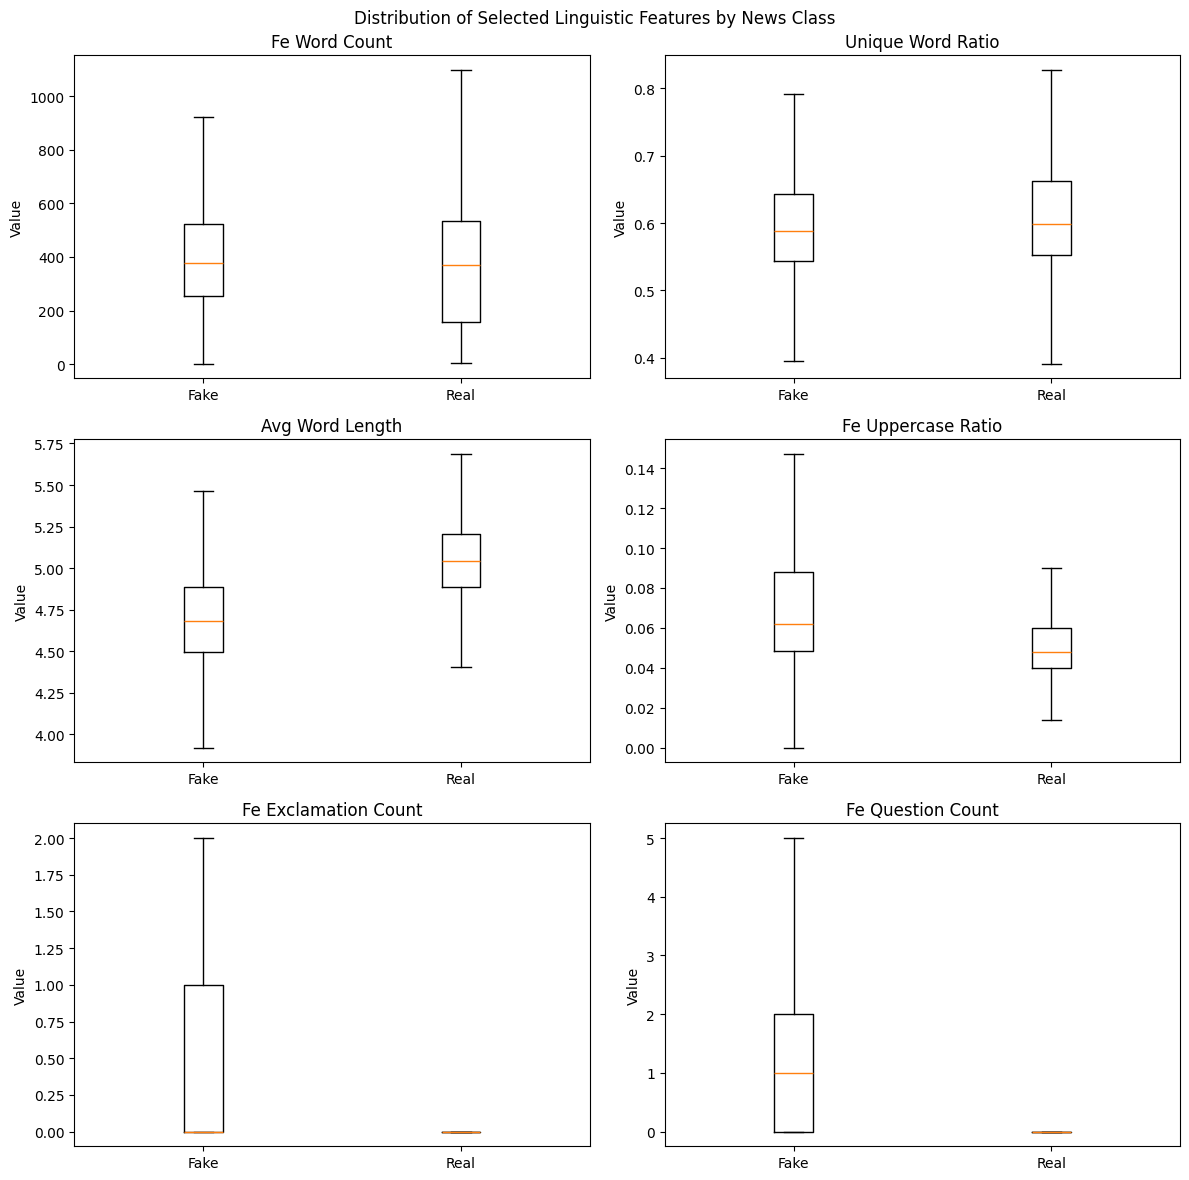

C:\Users\DELL\AppData\Local\Temp\ipykernel_16928\2913657970.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


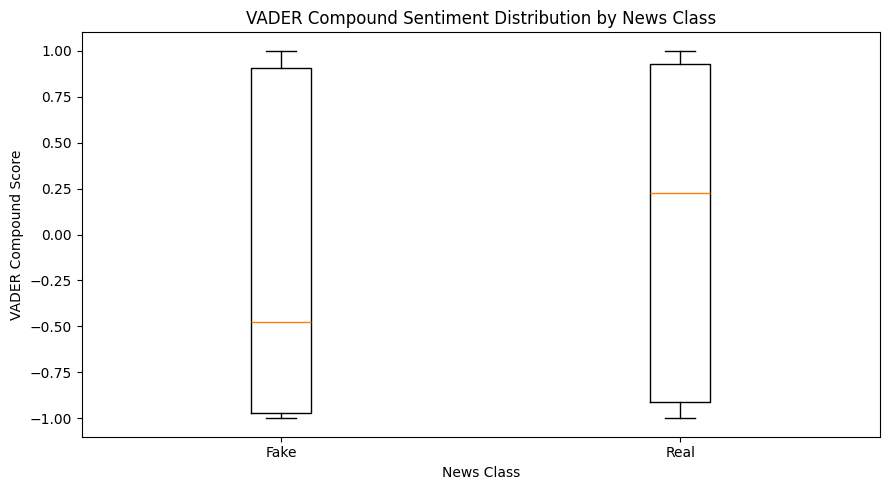

In [54]:
# Existing feature-level EDA plots

sentiment_by_class.T.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Average Sentiment Features by News Class")
plt.xlabel("Sentiment Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_sentiment_features_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

readability_by_class.T.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Average Readability Scores by News Class")
plt.xlabel("Readability Feature")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("eda_readability_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

stylometry_by_class.T.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Average Stylometric Features by News Class")
plt.xlabel("Stylometric Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_stylometric_features_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

ner_by_class.T.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Average Named Entity Counts by News Class")
plt.xlabel("Entity Type")
plt.ylabel("Average Entity Count")
plt.tight_layout()
plt.savefig("eda_named_entities_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

# Additional EDA: distributions rather than only class means.
plot_features = [
    "fe_word_count",
    "unique_word_ratio",
    "avg_word_length",
    "fe_uppercase_ratio",
    "fe_exclamation_count",
    "fe_question_count"
]
plot_features = [f for f in plot_features if f in df.columns]

if plot_features:
    ncols = 2
    nrows = int(np.ceil(len(plot_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    axes = np.asarray(axes).reshape(-1)

    for ax, feature in zip(axes, plot_features):
        fake_values = df.loc[df["label"] == 0, feature].replace([np.inf, -np.inf], np.nan).dropna()
        real_values = df.loc[df["label"] == 1, feature].replace([np.inf, -np.inf], np.nan).dropna()
        ax.boxplot([fake_values, real_values], labels=["Fake", "Real"], showfliers=False)
        ax.set_title(feature.replace("_", " ").title())
        ax.set_ylabel("Value")

    for ax in axes[len(plot_features):]:
        ax.axis("off")

    fig.suptitle("Distribution of Selected Linguistic Features by News Class")
    fig.tight_layout()
    fig.savefig("eda_selected_feature_distributions.png", dpi=300, bbox_inches="tight")
    plt.show()

if "vader_compound" in df.columns:
    plt.figure(figsize=(9, 5))
    plt.boxplot(
        [
            df.loc[df["label"] == 0, "vader_compound"].dropna(),
            df.loc[df["label"] == 1, "vader_compound"].dropna()
        ],
        labels=["Fake", "Real"],
        showfliers=False
    )
    plt.title("VADER Compound Sentiment Distribution by News Class")
    plt.xlabel("News Class")
    plt.ylabel("VADER Compound Score")
    plt.tight_layout()
    plt.savefig("eda_vader_compound_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


### PART O — SAVE ENGINEERED DATASET

In [55]:
df.to_csv(
    "fake_news_feature_engineered.csv",
    index=False
)


### PART P — SAVE NUMERICAL FEATURES

In [56]:
final_features = df[
    feature_columns + ["label"]
]


final_features.to_csv(
    "fake_news_numerical_features.csv",
    index=False
)


### PART Q — SAVE FEATURE SUMMARY

In [57]:
feature_summary.to_csv(
    "feature_statistics_by_class.csv"
)


## FINAL OUTPUT

In [58]:



print(
    "PHASE 2 — FEATURE ENGINEERING COMPLETED SUCCESSFULLY"
)



print(
    "\nDataset Shape:",
    df.shape
)

print(
    "Title TF-IDF Matrix:",
    X_title_tfidf.shape
)

print(
    "Body TF-IDF Matrix:",
    X_body_tfidf.shape
)

print(
    "Numerical Engineered Features:",
    len(feature_columns)
)


print("\nSaved Files:")

print(
    "1. fake_news_feature_engineered.csv"
)

print(
    "2. fake_news_numerical_features.csv"
)

print(
    "3. feature_statistics_by_class.csv"
)

print(
    "\nPhase 2 Completed Successfully!")

PHASE 2 — FEATURE ENGINEERING COMPLETED SUCCESSFULLY

Dataset Shape: (44689, 33)
Title TF-IDF Matrix: (44689, 10000)
Body TF-IDF Matrix: (44689, 10000)
Numerical Engineered Features: 18

Saved Files:
1. fake_news_feature_engineered.csv
2. fake_news_numerical_features.csv
3. feature_statistics_by_class.csv

Phase 2 Completed Successfully!


<h2><b>Model Training & Evaluation

# PHASE 3 — MODEL TRAINING & EVALUATION

## 1. IMPORT LIBRARIES

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# XGBoost is used as the gradient-boosting classifier.
%pip install -q xgboost
from xgboost import XGBClassifier



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 2. SETTINGS AND LOAD DATA

In [60]:


RANDOM_STATE = 42

N_SPLITS = 5


df = pd.read_csv(
    "fake_news_feature_engineered.csv"
)




print("PHASE 3 — MODEL TRAINING & EVALUATION")



print(
    "\nOriginal Dataset Shape:",
    df.shape
)


PHASE 3 — MODEL TRAINING & EVALUATION

Original Dataset Shape: (44689, 33)


C:\Users\DELL\AppData\Local\Temp\ipykernel_16928\3141688061.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## 4. FIX LABELS

In [61]:
print("\nOriginal Labels:")

print(
    df["label"].unique()
)


# ------------------------------------------------------------
# Convert Fake / Real to 0 / 1
# If labels are already numeric, keep them unchanged
# ------------------------------------------------------------

if df["label"].dtype == "object":

    df["label"] = (

        df["label"]

        .astype(str)

        .str.strip()

        .str.lower()

        .map({

            "fake": 0,

            "real": 1

        })

    )


# Convert labels to numeric

df["label"] = pd.to_numeric(

    df["label"],

    errors="coerce"

)


# Remove invalid labels

df = df.dropna(

    subset=["label"]

)


# Convert to integer

df["label"] = df["label"].astype(int)


# Target variable

y = df["label"]


print("\nFinal Labels:")

print(
    sorted(
        y.unique()
    )
)


print("\nClass Distribution:")

print(
    y.value_counts()
)


Original Labels:
[0 1]

Final Labels:
[np.int64(0), np.int64(1)]

Class Distribution:
label
0    23478
1    21211
Name: count, dtype: int64


## 5. PREPARE TEXT

In [62]:

df["combined_text"] = (

    df["combined_text"]

    .fillna("")

    .astype(str)

)



## 6. TF-IDF FEATURE EXTRACTION

In [63]:
print("CONFIGURING LEAKAGE-SAFE TF-IDF FEATURES")

tfidf_params = {
    "ngram_range": (1, 2),
    "max_features": 10000,
    "sublinear_tf": True,
    "stop_words": "english"
}

print("TF-IDF configuration:", tfidf_params)
print(
    "TF-IDF is intentionally fitted inside each cross-validation training fold "
    "rather than on the complete dataset."
)


CONFIGURING LEAKAGE-SAFE TF-IDF FEATURES
TF-IDF configuration: {'ngram_range': (1, 2), 'max_features': 10000, 'sublinear_tf': True, 'stop_words': 'english'}
TF-IDF is intentionally fitted inside each cross-validation training fold rather than on the complete dataset.


## 7. NUMERICAL FEATURES

In [64]:


numerical_features = [

    "vader_positive",

    "vader_negative",

    "vader_neutral",

    "vader_compound",

    "fe_word_count",

    "fe_char_count",

    "unique_word_ratio",

    "avg_word_length",

    "fe_uppercase_ratio",

    "fe_exclamation_count",

    "fe_question_count",

    "stopword_density"

]


# Check available features

available_features = [

    feature

    for feature in numerical_features

    if feature in df.columns

]


print(

    "\nNumerical Features Found:",

    len(available_features)

)


print(

    available_features

)


Numerical Features Found: 11
['vader_positive', 'vader_negative', 'vader_neutral', 'vader_compound', 'fe_word_count', 'unique_word_ratio', 'avg_word_length', 'fe_uppercase_ratio', 'fe_exclamation_count', 'fe_question_count', 'stopword_density']


## 8. PREPARE NUMERICAL FEATURES

In [65]:
X_numeric = (
    df[available_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Prepared numerical feature columns:", available_features)


Prepared numerical feature columns: ['vader_positive', 'vader_negative', 'vader_neutral', 'vader_compound', 'fe_word_count', 'unique_word_ratio', 'avg_word_length', 'fe_uppercase_ratio', 'fe_exclamation_count', 'fe_question_count', 'stopword_density']


## 9. SCALE NUMERICAL FEATURES

In [66]:
print(
    "Numerical scaling is performed inside the modelling pipeline "
    "for each training fold to prevent information leakage."
)


Numerical scaling is performed inside the modelling pipeline for each training fold to prevent information leakage.


## 10. COMBINE TF-IDF + NUMERICAL FEATURES

In [67]:
print(
    "The final feature matrix is constructed inside each model pipeline. "
    "This keeps TF-IDF fitting and numerical scaling within the cross-validation folds."
)


The final feature matrix is constructed inside each model pipeline. This keeps TF-IDF fitting and numerical scaling within the cross-validation folds.


## 11. DEFINE MODELS

In [68]:
# Raw modelling inputs. The subject and date columns are deliberately excluded.
model_columns = ["combined_text"] + available_features
X_model_input = df[model_columns].copy()
X_text_input = df["combined_text"].fillna("").astype(str)

# Shared preprocessing for models that use TF-IDF + numerical features.
combined_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(**tfidf_params),
            "combined_text"
        ),
        (
            "num",
            StandardScaler(),
            available_features
        )
    ],
    remainder="drop",
    sparse_threshold=0.3
)


def make_combined_pipeline(model):
    return Pipeline([
        ("preprocess", combined_preprocessor),
        ("model", model)
    ])


models = {
    "Logistic Regression": make_combined_pipeline(
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    ),
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", MultinomialNB())
    ]),
    "Random Forest": make_combined_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    "XGBoost": make_combined_pipeline(
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )
    )
}

print("Models prepared using leakage-safe pipelines.")


Models prepared using leakage-safe pipelines.


## 12. CROSS-VALIDATION

In [69]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(
    "Using stratified five-fold cross-validation. "
    "All learned preprocessing is fitted within each training fold."
)


Using stratified five-fold cross-validation. All learned preprocessing is fitted within each training fold.


## 13. EVALUATION METRICS

In [70]:


scoring = {

    "accuracy":

        "accuracy",


    "precision":

        "precision_macro",


    "recall":

        "recall_macro",


    "f1_macro":

        "f1_macro",


    "f1_weighted":

        "f1_weighted",


    "roc_auc":

        "roc_auc"

}

## 14. TRAIN AND EVALUATE MODELS

In [71]:
results = []

for model_name, model in models.items():
    print("TRAINING:", model_name)

    # Naive Bayes uses TF-IDF-only input because standardised numerical features
    # can contain negative values and are unsuitable for the Multinomial NB formulation.
    X_input = X_text_input if model_name == "Multinomial Naive Bayes" else X_model_input

    scores = cross_validate(
        model,
        X_input,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Macro": scores["test_f1_macro"].mean(),
        "F1 Weighted": scores["test_f1_weighted"].mean(),
        "AUC-ROC": scores["test_roc_auc"].mean()
    })

    print("Accuracy:", round(results[-1]["Accuracy"], 4))
    print("Precision:", round(results[-1]["Precision"], 4))
    print("Recall:", round(results[-1]["Recall"], 4))
    print("F1 Macro:", round(results[-1]["F1 Macro"], 4))
    print("F1 Weighted:", round(results[-1]["F1 Weighted"], 4))
    print("AUC-ROC:", round(results[-1]["AUC-ROC"], 4))


TRAINING: Logistic Regression
Accuracy: 0.9922
Precision: 0.9921
Recall: 0.9923
F1 Macro: 0.9922
F1 Weighted: 0.9922
AUC-ROC: 0.9989
TRAINING: Multinomial Naive Bayes
Accuracy: 0.9566
Precision: 0.9564
Recall: 0.9566
F1 Macro: 0.9565
F1 Weighted: 0.9566
AUC-ROC: 0.9904
TRAINING: Random Forest
Accuracy: 0.9981
Precision: 0.9981
Recall: 0.9981
F1 Macro: 0.9981
F1 Weighted: 0.9981
AUC-ROC: 1.0
TRAINING: XGBoost
Accuracy: 0.9985
Precision: 0.9985
Recall: 0.9985
F1 Macro: 0.9985
F1 Weighted: 0.9985
AUC-ROC: 0.9999


In [72]:
print("Model evaluation completed using leakage-safe pipelines.")

Model evaluation completed using leakage-safe pipelines.


## 15. MODEL COMPARISON

In [73]:


results_df = pd.DataFrame(

    results

)


# Sort by F1 Macro

results_df = (

    results_df

    .sort_values(

        by="F1 Macro",

        ascending=False

    )

    .reset_index(

        drop=True

    )

)




print(

    "MODEL COMPARISON RESULTS"

)



print(

    results_df.to_string(

        index=False

    )

)


MODEL COMPARISON RESULTS
                  Model  Accuracy  Precision   Recall  F1 Macro  F1 Weighted  AUC-ROC
                XGBoost  0.998456   0.998454 0.998451  0.998452     0.998456 0.999930
          Random Forest  0.998098   0.998102 0.998085  0.998093     0.998098 0.999956
    Logistic Regression  0.992213   0.992125 0.992270  0.992194     0.992213 0.998874
Multinomial Naive Bayes  0.956634   0.956438 0.956642  0.956532     0.956639 0.990372


## 16. SAVE MODEL RESULTS

In [74]:

results_df.to_csv(

    "phase3_model_results.csv",

    index=False

)


## 17. MODEL PERFORMANCE GRAPH

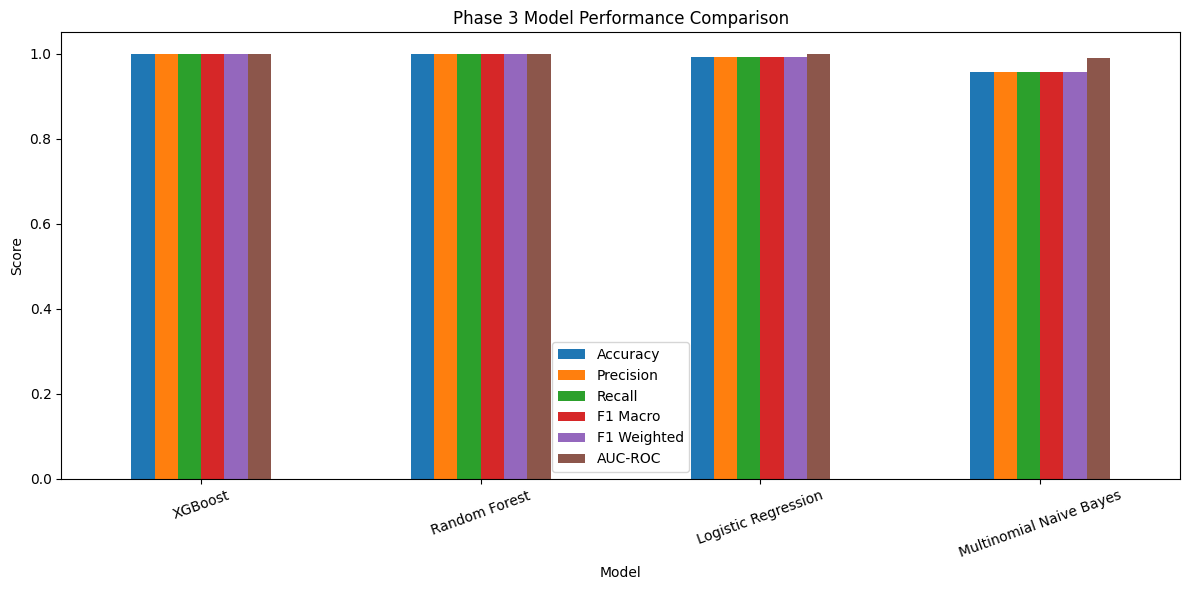

In [75]:


results_df.set_index(

    "Model"

)[

    [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Macro",

        "F1 Weighted",

        "AUC-ROC"

    ]

].plot(

    kind="bar",

    figsize=(12, 6)

)


plt.title(

    "Phase 3 Model Performance Comparison"

)


plt.ylabel(

    "Score"

)


plt.ylim(

    0,

    1.05

)


plt.xticks(

    rotation=20

)


plt.tight_layout()


plt.show()

## 18. FEATURE ABLATION STUDY AND SELECT TOP 2 MODELS

The ablation study controls the classifier and changes the feature representation so that the contribution of sentiment and stylometric features can be evaluated directly.



FEATURE ABLATION RESULTS
          Feature Representation  Accuracy  F1 Macro  AUC-ROC
              TF-IDF + Sentiment  0.993444  0.993428 0.999550
                     TF-IDF only  0.993041  0.993024 0.999534
TF-IDF + Sentiment + Stylometric  0.992213  0.992194 0.998874
            TF-IDF + Stylometric  0.992101  0.992082 0.998908


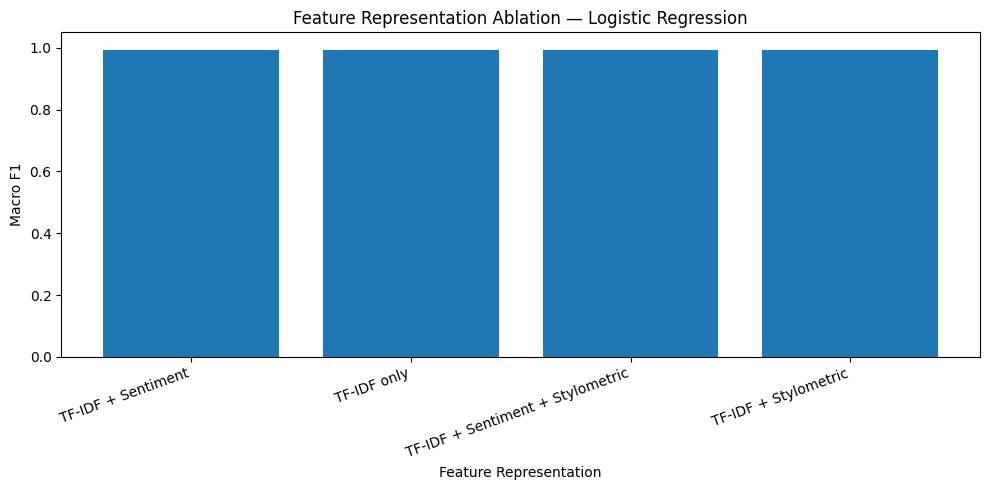


Top 2 Performing Models:
✓ XGBoost
✓ Random Forest


In [76]:
# Feature ablation is designed to answer RQ2 while holding the classifier constant.
# Logistic Regression is used as the controlled classifier because it is efficient and
# provides a stable baseline for high-dimensional text representations.

sentiment_features = [
    f for f in [
        "vader_positive",
        "vader_negative",
        "vader_neutral",
        "vader_compound"
    ] if f in available_features
]

stylometric_features = [
    f for f in [
        "fe_word_count",
        "fe_char_count",
        "unique_word_ratio",
        "avg_word_length",
        "fe_uppercase_ratio",
        "fe_exclamation_count",
        "fe_question_count",
        "stopword_density"
    ] if f in available_features
]

ablation_specs = {
    "TF-IDF only": None,
    "TF-IDF + Sentiment": sentiment_features,
    "TF-IDF + Stylometric": stylometric_features,
    "TF-IDF + Sentiment + Stylometric": sentiment_features + stylometric_features
}

ablation_results = []

for feature_set_name, numeric_cols in ablation_specs.items():
    if numeric_cols is None:
        ablation_model = Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_params)),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ])
        X_ablation = X_text_input
    else:
        ablation_preprocessor = ColumnTransformer(
            transformers=[
                ("text", TfidfVectorizer(**tfidf_params), "combined_text"),
                ("num", StandardScaler(), numeric_cols)
            ],
            remainder="drop",
            sparse_threshold=0.3
        )
        ablation_model = Pipeline([
            ("preprocess", ablation_preprocessor),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ])
        X_ablation = df[["combined_text"] + numeric_cols].copy()

    scores = cross_validate(
        ablation_model,
        X_ablation,
        y,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1_macro": "f1_macro", "roc_auc": "roc_auc"},
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    ablation_results.append({
        "Feature Representation": feature_set_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "F1 Macro": scores["test_f1_macro"].mean(),
        "AUC-ROC": scores["test_roc_auc"].mean()
    })

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    "F1 Macro", ascending=False
).reset_index(drop=True)

print("\nFEATURE ABLATION RESULTS")
print(ablation_results_df.to_string(index=False))

ablation_results_df.to_csv("feature_ablation_results.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(
    ablation_results_df["Feature Representation"],
    ablation_results_df["F1 Macro"]
)
plt.title("Feature Representation Ablation — Logistic Regression")
plt.xlabel("Feature Representation")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("feature_ablation_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# Select the two strongest models from the corrected Phase 3 comparison.
top_models = results_df.head(2)["Model"].tolist()

print("\nTop 2 Performing Models:")
for model_name in top_models:
    print("✓", model_name)


# 19. SIMPLE GRID SEARCH

In [77]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },
    "Random Forest": {
        "model__max_depth": [None, 20],
        "model__min_samples_split": [2, 5]
    },
    "XGBoost": {
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.1]
    },
    "Multinomial Naive Bayes": {
        "model__alpha": [0.1, 1.0]
    }
}


## 20. TUNE TOP MODELS

In [78]:
tuned_results = []
best_models = {}

for model_name in top_models:
    print("GRID SEARCH:", model_name)

    model = models[model_name]
    X_input = X_text_input if model_name == "Multinomial Naive Bayes" else X_model_input

    # Parameters are prefixed with the pipeline step name so that GridSearchCV
    # tunes the classifier while preprocessing remains inside each CV fold.
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        return_train_score=False
    )

    grid.fit(X_input, y)

    best_models[model_name] = grid.best_estimator_

    tuned_results.append({
        "Model": model_name,
        "Best F1 Macro": grid.best_score_
    })

    print("Best Parameters:", grid.best_params_)
    print("Best F1 Macro:", round(grid.best_score_, 4))


GRID SEARCH: XGBoost
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3}
Best F1 Macro: 0.9953
GRID SEARCH: Random Forest
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5}
Best F1 Macro: 0.993


## 21. TUNED MODEL RESULTS

In [79]:


tuned_results_df = pd.DataFrame(

    tuned_results

)




print(

    "TUNED MODEL RESULTS"

)



print(

    tuned_results_df.to_string(

        index=False

    )

)

TUNED MODEL RESULTS
        Model  Best F1 Macro
      XGBoost       0.995312
Random Forest       0.992975


## 22. FIND BEST FINAL MODEL

In [80]:


best_row = (

    tuned_results_df

    .sort_values(

        by="Best F1 Macro",

        ascending=False

    )

    .iloc[0]

)


best_tuned_model_name = (

    best_row["Model"]

)


best_f1_score = (

    best_row["Best F1 Macro"]

)


best_model = (

    best_models[

        best_tuned_model_name

    ]

)




print(

    "FINAL BEST MODEL"

)




print(

    "Best Model:",

    best_tuned_model_name

)


print(

    "Best F1 Macro:",

    round(

        best_f1_score,

        4

    )

)


FINAL BEST MODEL
Best Model: XGBoost
Best F1 Macro: 0.9953


## 23. TRAIN FINAL MODEL

In [81]:
print("\nTraining Final Model...")

final_input = X_text_input if best_tuned_model_name == "Multinomial Naive Bayes" else X_model_input
best_model.fit(final_input, y)

print("Final Model Trained Successfully!")



Training Final Model...
Final Model Trained Successfully!


## 24. SAVE FINAL RESULTS

In [82]:


final_results = pd.DataFrame({

    "Best Model":

    [

        best_tuned_model_name

    ],


    "Best F1 Macro":

    [

        best_f1_score

    ]

})


final_results.to_csv(

    "final_best_model_results.csv",

    index=False

)


## 25. FINAL OUTPUT

In [83]:
print(
    "PHASE 3 — COMPLETED SUCCESSFULLY"
)

print(
    "\nDataset Shape:",
    df.shape
)

print(
    "TF-IDF Maximum Features:",
    tfidf_params["max_features"]
)

print(
    "Numerical Features:",
    len(available_features)
)

print(
    "\nBest Model:",
    best_tuned_model_name
)

print(
    "Best F1 Macro:",
    round(best_f1_score, 4)
)

print(
    "\nSaved Files:"
)

print("✓ phase3_model_results.csv")
print("✓ final_best_model_results.csv")
print("✓ feature_ablation_results.csv")
print("✓ feature_ablation_macro_f1.png")

print(
    "\nPhase 3 Completed Successfully!"
)


PHASE 3 — COMPLETED SUCCESSFULLY

Dataset Shape: (44689, 33)
TF-IDF Maximum Features: 10000
Numerical Features: 11

Best Model: XGBoost
Best F1 Macro: 0.9953

Saved Files:
✓ phase3_model_results.csv
✓ final_best_model_results.csv
✓ feature_ablation_results.csv
✓ feature_ablation_macro_f1.png

Phase 3 Completed Successfully!


<h2><b>Interpretability & Insights

## PHASE 4 — INTERPRETABILITY & INSIGHTS

### 1. IMPORT LIBRARIES

In [84]:


print("PHASE 4 ANALYSIS STARTED")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    accuracy_score
)


PHASE 4 ANALYSIS STARTED


### 2. PREPARE DATA

In [85]:

# Make sure labels are numeric

if df["label"].dtype == "object":

    df["label"] = (

        df["label"]

        .astype(str)

        .str.lower()

        .str.strip()

        .map({

            "fake": 0,

            "real": 1

        })

    )


df["label"] = pd.to_numeric(

    df["label"],

    errors="coerce"

)


df = df.dropna(

    subset=["label"]

)


df["label"] = df["label"].astype(int)


y = df["label"]

### 3. CREATE CROSS-VALIDATED PREDICTIONS

In [86]:
print("\nGenerating leakage-safe out-of-fold predictions...")

X_phase4 = X_text_input if best_tuned_model_name == "Multinomial Naive Bayes" else X_model_input

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_pred = cross_val_predict(
    best_model,
    X_phase4,
    y,
    cv=cv,
    method="predict",
    n_jobs=-1
)

y_prob = cross_val_predict(
    best_model,
    X_phase4,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Predictions generated successfully using fold-specific preprocessing!")



Generating leakage-safe out-of-fold predictions...
Predictions generated successfully using fold-specific preprocessing!


### 4. OVERALL MODEL PERFORMANCE

In [87]:




print("OVERALL MODEL PERFORMANCE")


accuracy = accuracy_score(

    y,

    y_pred

)


auc_score = roc_auc_score(

    y,

    y_prob

)


print(

    "Accuracy:",

    round(

        accuracy,

        4

    )

)


print(

    "AUC-ROC:",

    round(

        auc_score,

        4

    )

)


print("\nClassification Report:")


print(

    classification_report(

        y,

        y_pred,

        target_names=[

            "Fake",

            "Real"

        ]

    )

)

OVERALL MODEL PERFORMANCE
Accuracy: 0.9982
AUC-ROC: 1.0

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00     23478
        Real       1.00      1.00      1.00     21211

    accuracy                           1.00     44689
   macro avg       1.00      1.00      1.00     44689
weighted avg       1.00      1.00      1.00     44689



### 5. CONFUSION MATRIX


Confusion Matrix:
[[23436    42]
 [   39 21172]]


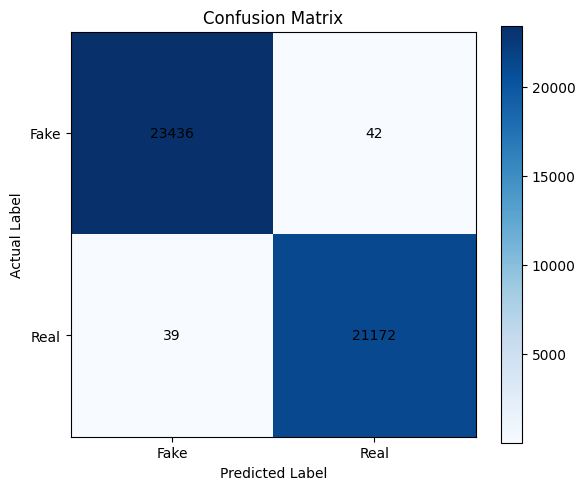

In [88]:


cm = confusion_matrix(

    y,

    y_pred

)


print("\nConfusion Matrix:")

print(cm)


plt.figure(

    figsize=(6, 5)

)


plt.imshow(

    cm,

    interpolation="nearest",
    cmap = "Blues"

)


plt.title(

    "Confusion Matrix"

)


plt.xlabel(

    "Predicted Label"

)


plt.ylabel(

    "Actual Label"

)


plt.xticks(

    [0, 1],

    ["Fake", "Real"]

)


plt.yticks(

    [0, 1],

    ["Fake", "Real"]

)


for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"

        )


plt.colorbar()


plt.tight_layout()


plt.show()

### 6. MISCLASSIFICATION ANALYSIS

In [89]:


df["prediction"] = y_pred

df["prediction_probability"] = y_prob


# Incorrect predictions

misclassified = df[

    df["label"]

    !=

    df["prediction"]

]




print("MISCLASSIFICATION ANALYSIS")



print(

    "Total Misclassified:",

    len(misclassified)

)


print(

    "Misclassification Rate:",

    round(

        len(misclassified) / len(df),

        4

    )

)


# Fake predicted as Real

fake_as_real = len(

    df[

        (df["label"] == 0)

        &

        (df["prediction"] == 1)

    ]

)


# Real predicted as Fake

real_as_fake = len(

    df[

        (df["label"] == 1)

        &

        (df["prediction"] == 0)

    ]

)


print(

    "Fake News predicted as Real:",

    fake_as_real

)


print(

    "Real News predicted as Fake:",

    real_as_fake

)

MISCLASSIFICATION ANALYSIS
Total Misclassified: 81
Misclassification Rate: 0.0018
Fake News predicted as Real: 42
Real News predicted as Fake: 39


### 7. SUBJECT-WISE PERFORMANCE

SUBJECT-WISE PERFORMANCE
        subject  Accuracy  Samples
       politics  0.996783   6838.0
Government News  0.996815   1570.0
   politicsNews  0.997148  11220.0
    Middle-east  0.997429    778.0
        US_News  0.997446    783.0
      left-news  0.998206   4459.0
      worldnews  0.999299   9991.0
           News  0.999669   9050.0


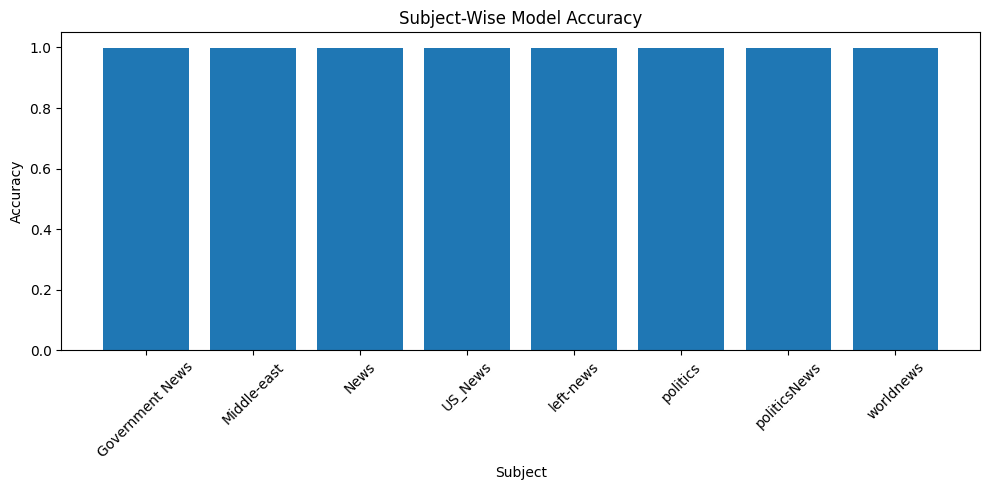

In [90]:


if "subject" in df.columns:


    print("SUBJECT-WISE PERFORMANCE")




    subject_results = (

        df

        .groupby("subject")

        .apply(

            lambda x:

            pd.Series({

                "Accuracy":

                accuracy_score(

                    x["label"],

                    x["prediction"]

                ),

                "Samples":

                len(x)

            }),

            include_groups=False

        )

        .reset_index()

    )


    print(

        subject_results

        .sort_values(

            "Accuracy"

        )

        .to_string(

            index=False

        )

    )


    # Plot

    plt.figure(

        figsize=(10, 5)

    )


    plt.bar(

        subject_results["subject"],

        subject_results["Accuracy"]

    )


    plt.title(

        "Subject-Wise Model Accuracy"

    )


    plt.xlabel(

        "Subject"

    )


    plt.ylabel(

        "Accuracy"

    )


    plt.xticks(

        rotation=45

    )


    plt.ylim(

        0,

        1.05

    )


    plt.tight_layout()


    plt.show()


else:

    print(

        "\nSubject column not available."

    )


### 8. TEMPORAL PERFORMANCE ANALYSIS

TEMPORAL PERFORMANCE ANALYSIS
  year  Accuracy  Samples
2015.0  0.997041    338.0
2016.0  0.999435   7077.0
2017.0  0.998653   4453.0


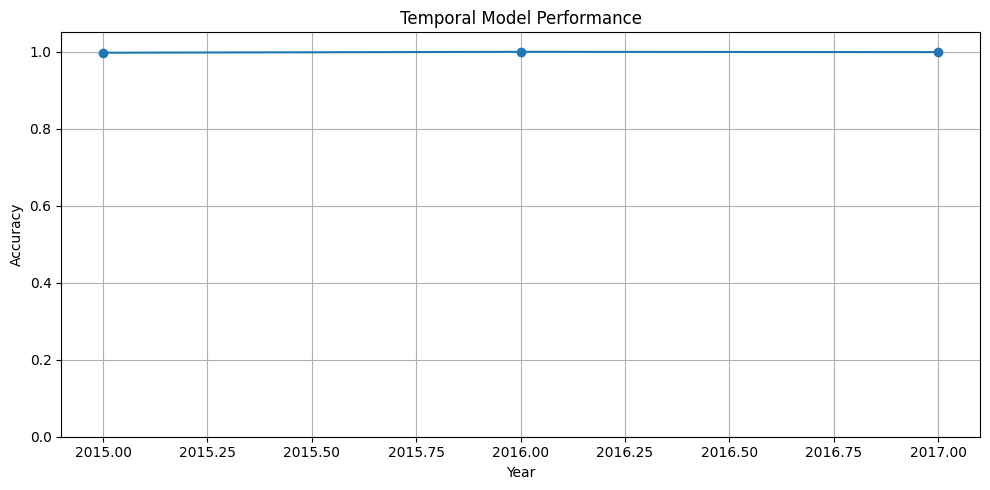

In [91]:


if "date" in df.columns:

    print("TEMPORAL PERFORMANCE ANALYSIS")



    df["date"] = pd.to_datetime(

        df["date"],

        errors="coerce"

    )


    df["year"] = df["date"].dt.year


    temporal_results = (

        df

        .dropna(

            subset=["year"]

        )

        .groupby("year")

        .apply(

            lambda x:

            pd.Series({

                "Accuracy":

                accuracy_score(

                    x["label"],

                    x["prediction"]

                ),

                "Samples":

                len(x)

            }),

            include_groups=False

        )

        .reset_index()

    )


    print(

        temporal_results

        .sort_values(

            "year"

        )

        .to_string(

            index=False

        )

    )


    # Plot

    plt.figure(

        figsize=(10, 5)

    )


    plt.plot(

        temporal_results["year"],

        temporal_results["Accuracy"],

        marker="o"

    )


    plt.title(

        "Temporal Model Performance"

    )


    plt.xlabel(

        "Year"

    )


    plt.ylabel(

        "Accuracy"

    )


    plt.ylim(

        0,

        1.05

    )


    plt.grid(

        True

    )


    plt.tight_layout()


    plt.show()


else:

    print(

        "\nDate column not available."

    )


### 9. SHAP GLOBAL FEATURE IMPORTANCE

SHAP ANALYSIS



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
SHAP analysis completed with interpretable feature names.


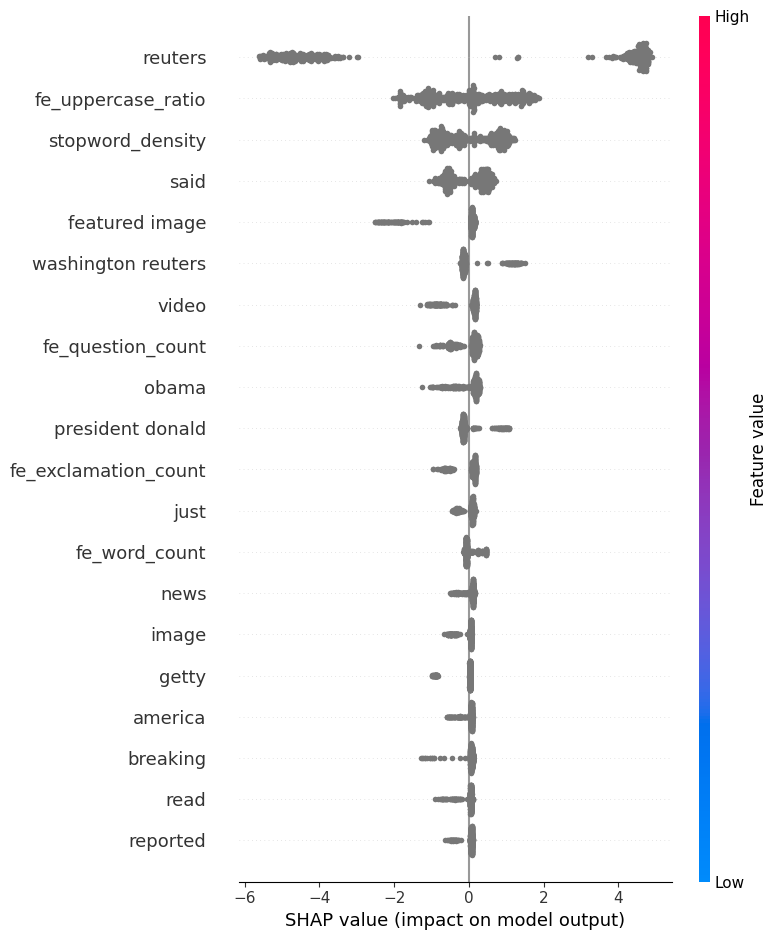

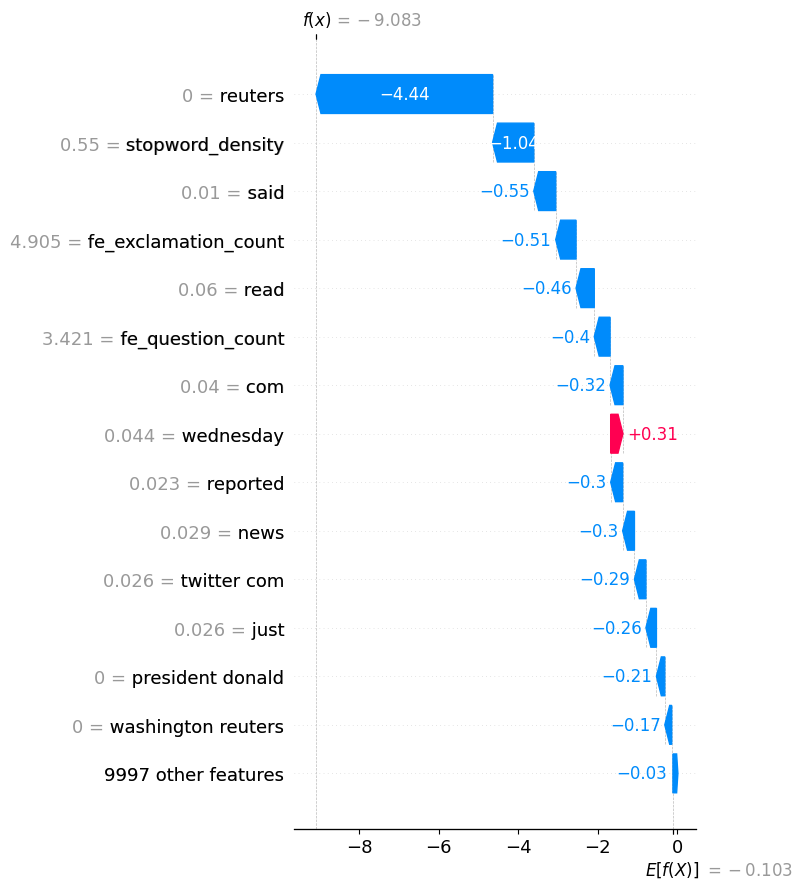

In [92]:
print("SHAP ANALYSIS")

try:
    %pip install -q shap
    import shap

    if best_tuned_model_name == "XGBoost":
        shap_preprocessor = best_model.named_steps["preprocess"]
        shap_model = best_model.named_steps["model"]
        X_shap_input = X_model_input

        # Transform a reproducible sample using the already-fitted final preprocessing pipeline.
        sample_size = min(500, len(X_shap_input))
        sample_indices = np.random.RandomState(42).choice(
            len(X_shap_input), sample_size, replace=False
        )
        X_sample_raw = X_shap_input.iloc[sample_indices]
        X_sample = shap_preprocessor.transform(X_sample_raw)

        feature_names = shap_preprocessor.get_feature_names_out()
        feature_names = [
            name.replace("text__", "").replace("num__", "")
            for name in feature_names
        ]

        explainer = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(X_sample)

        if isinstance(shap_values, list):
            shap_values_plot = shap_values[1]
        else:
            shap_values_plot = shap_values

        print("SHAP analysis completed with interpretable feature names.")

        # Global explanation.
        plt.figure()
        shap.summary_plot(
            shap_values_plot,
            X_sample,
            feature_names=feature_names,
            show=False,
            max_display=20
        )
        plt.tight_layout()
        plt.savefig("shap_global_feature_importance.png", dpi=300, bbox_inches="tight")
        plt.show()

        # Local explanation for one selected article.
        local_index = 0
        local_explanation = shap.Explanation(
            values=shap_values_plot[local_index],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
            data=X_sample[local_index].toarray().ravel() if hasattr(X_sample[local_index], "toarray") else X_sample[local_index],
            feature_names=feature_names
        )

        plt.figure(figsize=(10, 8))
        shap.plots.waterfall(local_explanation, max_display=15, show=False)
        plt.tight_layout()
        plt.savefig("shap_local_waterfall.png", dpi=300, bbox_inches="tight")
        plt.show()

    else:
        print(
            "SHAP global/local tree explanation is configured for XGBoost. "
            "The selected final model was:", best_tuned_model_name
        )

except Exception as e:
    print("SHAP analysis skipped:", str(e))


### 10. LEAKAGE AUDIT

In [93]:


print("LEAKAGE AUDIT")



if "subject" in df.columns:

    print(

        "Subject column detected."

    )


    print(

        "The subject feature is NOT directly used "

        "in the numerical feature matrix."

    )


    print(

        "A separate subject-based analysis is performed "

        "to identify possible dataset bias."

    )


    print(

        "\nSubject distribution by class:"

    )


    leakage_table = pd.crosstab(

        df["subject"],

        df["label"],

        normalize="index"

    )


    print(

        leakage_table

    )


else:

    print(

        "Subject column not available."

    )

LEAKAGE AUDIT
Subject column detected.
The subject feature is NOT directly used in the numerical feature matrix.
A separate subject-based analysis is performed to identify possible dataset bias.

Subject distribution by class:
label              0    1
subject                  
Government News  1.0  0.0
Middle-east      1.0  0.0
News             1.0  0.0
US_News          1.0  0.0
left-news        1.0  0.0
politics         1.0  0.0
politicsNews     0.0  1.0
worldnews        0.0  1.0


### 11. SAVE PHASE 4 RESULTS

In [94]:

df.to_csv(

    "phase4_predictions_and_analysis.csv",

    index=False

)


subject_results.to_csv(

    "subject_wise_results.csv",

    index=False

) if "subject" in df.columns else None


if "date" in df.columns:

    temporal_results.to_csv(

        "temporal_results.csv",

        index=False

    )

### 12. FINAL OUTPUT

In [95]:

print(

    "PHASE 4 — COMPLETED SUCCESSFULLY"

)




print(

    "\nBest Model:",

    best_tuned_model_name

)


print(

    "Accuracy:",

    round(

        accuracy,

        4

    )

)


print(

    "AUC-ROC:",

    round(

        auc_score,

        4

    )

)


print(

    "Misclassified Samples:",

    len(misclassified)

)


print(

    "\nOutput Files:"

)


print(

    "✓ phase4_predictions_and_analysis.csv"

)


if "subject" in df.columns:

    print(

        "✓ subject_wise_results.csv"

    )


if "date" in df.columns:

    print(

        "✓ temporal_results.csv"

    )


print(

    "\nPHASE 4 ANALYSIS COMPLETED!"

)

PHASE 4 — COMPLETED SUCCESSFULLY

Best Model: XGBoost
Accuracy: 0.9982
AUC-ROC: 1.0
Misclassified Samples: 81

Output Files:
✓ phase4_predictions_and_analysis.csv
✓ subject_wise_results.csv
✓ temporal_results.csv

PHASE 4 ANALYSIS COMPLETED!
